In [1]:
# ===============================
# 0. Setup & Dataset Extraction
# ===============================
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Using GPU: ", tf.test.gpu_device_name())

from google.colab import drive
drive.mount('/content/drive')

# If dataset is in .rar, extract it
!apt install unrar
!pip install pyunpack patool

from pyunpack import Archive
rar_path = '/content/drive/MyDrive/Colab Dataset/data.rar'
extract_path = '/content/Dataset'
os.makedirs(extract_path, exist_ok=True)
Archive(rar_path).extractall(extract_path)

# ===============================
# 1. Dataset Preparation
# ===============================
data_root = '/content/Dataset/data/Recognition'  # adjust if needed
train_dir = os.path.join(data_root, 'train')
val_dir = os.path.join(data_root, 'validation')
test_dir = os.path.join(data_root, 'test')

image_size = (224, 224)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=seed
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False,
    seed=seed
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Num GPUs Available:  1
Using GPU:  /device:GPU:0
Mounted at /content/drive
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.5/86.5 kB 4.4 MB/s eta 0:00:00
Found 26097 files belonging to 9 classes.
Found 1634 files belonging to 9 classes.
Found 1144 files belonging to 9 classes.
Classes: ['1000_taka', '100_taka', '10_taka', '200_taka', '20_taka', '2_taka', '500_taka', '50_taka', '5_taka']


In [2]:
# Optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [4]:
# ===============================
# 2. Build InceptionV3 Model (Feature Extraction Only)
# ===============================
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models

def create_inceptionv3(input_shape=(224,224,3), num_classes=9):
    base_model = InceptionV3(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False   # Freeze backbone

    inputs = layers.Input(shape=input_shape)
    x = tf.keras.applications.inception_v3.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model

model = create_inceptionv3(input_shape=(224,224,3), num_classes=num_classes)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │        18,441 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,821,225 (83.24 MB)

 Trainable params: 18,441 (72.04 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [5]:

# ===============================
# 3. Training (Feature Extraction Only)
# ===============================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_inceptionv3_currency.h5", save_best_only=True, monitor="val_loss", verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

epochs = 30
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks)

Epoch 1/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.2075 - loss: 2.3588
Epoch 1: val_loss improved from inf to 1.24063, saving model to best_inceptionv3_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 97s 95ms/step - accuracy: 0.2076 - loss: 2.3584 - val_accuracy: 0.6144 - val_loss: 1.2406 - learning_rate: 1.0000e-04
Epoch 2/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4838 - loss: 1.4790
Epoch 2: val_loss improved from 1.24063 to 0.94122, saving model to best_inceptionv3_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 107s 68ms/step - accuracy: 0.4839 - loss: 1.4788 - val_accuracy: 0.7173 - val_loss: 0.9412 - learning_rate: 1.0000e-04
Epoch 3/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5927 - loss: 1.1921
Epoch 3: val_loss improved from 0.94122 to 0.79880, saving model to best_inceptionv3_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.5927 - loss: 1.1921 - val_accuracy: 0.7699 - val_loss: 0.7988 - learning_rate: 1.0000e-04
Epoch 4/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6438 - loss: 1.0347
Epoch 4: val_loss improved from 0.79880 to 0.70673, saving model to best_inceptionv3_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - accuracy: 0.6438 - loss: 1.0347 - val_accuracy: 0.8023 - val_loss: 0.7067 - learning_rate: 1.0000e-04
Epoch 5/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6765 - loss: 0.9611
Epoch 5: val_loss improved from 0.70673 to 0.64816, saving model to best_inceptionv3_currency.h5


...

816/816 ━━━━━━━━━━━━━━━━━━━━ 85s 71ms/step - accuracy: 0.7957 - loss: 0.6123 - val_accuracy: 0.8929 - val_loss: 0.3877 - learning_rate: 1.0000e-04
Epoch 25/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7946 - loss: 0.6041
Epoch 25: val_loss did not improve from 0.38769
816/816 ━━━━━━━━━━━━━━━━━━━━ 79s 67ms/step - accuracy: 0.7946 - loss: 0.6041 - val_accuracy: 0.8935 - val_loss: 0.3883 - learning_rate: 1.0000e-04
Epoch 26/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8031 - loss: 0.5921
Epoch 26: val_loss improved from 0.38769 to 0.37923, saving model to best_inceptionv3_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 83s 68ms/step - accuracy: 0.8031 - loss: 0.5921 - val_accuracy: 0.8966 - val_loss: 0.3792 - learning_rate: 1.0000e-04
Epoch 27/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7961 - loss: 0.6036
Epoch 27: val_loss improved from 0.37923 to 0.37680, saving model to best_inceptionv3_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 57s 69ms/step - accuracy: 0.7961 - loss: 0.6036 - val_accuracy: 0.8941 - val_loss: 0.3768 - learning_rate: 1.0000e-04
Epoch 28/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7994 - loss: 0.5922
Epoch 28: val_loss did not improve from 0.37680
816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.7994 - loss: 0.5922 - val_accuracy: 0.8929 - val_loss: 0.3771 - learning_rate: 1.0000e-04
Epoch 29/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8031 - loss: 0.5974
Epoch 29: val_loss improved from 0.37680 to 0.37386, saving model to best_inceptionv3_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.8031 - loss: 0.5974 - val_accuracy: 0.8941 - val_loss: 0.3739 - learning_rate: 1.0000e-04
Epoch 30/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8030 - loss: 0.5950
Epoch 30: val_loss improved from 0.37386 to 0.37365, saving model to best_inceptionv3_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 57s 70ms/step - accuracy: 0.8030 - loss: 0.5950 - val_accuracy: 0.8972 - val_loss: 0.3737 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 30.


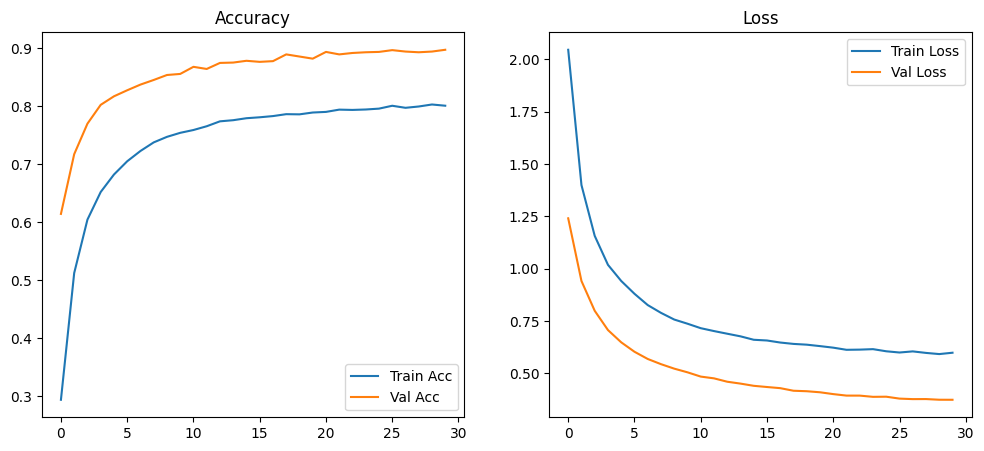

In [6]:
# ===============================
# 4. Plot Training Curves
# ===============================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")
plt.show()

In [7]:
# ===============================
# 5. Evaluation on Test Set
# ===============================
y_true, y_pred = [], []
for batch_images, batch_labels in test_ds:
    preds = model.predict(batch_images)
    preds_classes = np.argmax(preds, axis=1)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(preds_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


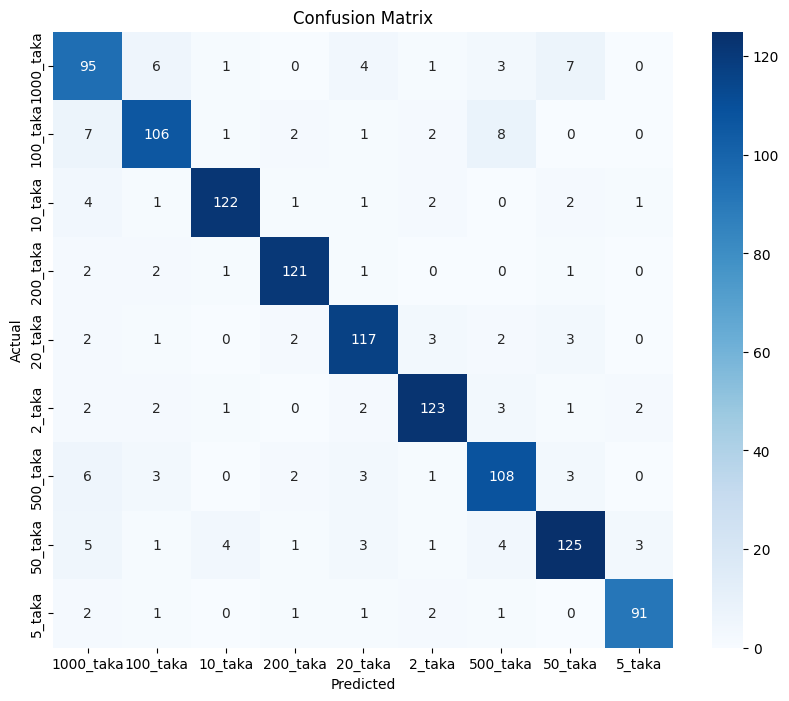

In [8]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

In [9]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

   1000_taka       0.76      0.81      0.79       117
    100_taka       0.86      0.83      0.85       127
     10_taka       0.94      0.91      0.92       134
    200_taka       0.93      0.95      0.94       128
     20_taka       0.88      0.90      0.89       130
      2_taka       0.91      0.90      0.91       136
    500_taka       0.84      0.86      0.85       126
     50_taka       0.88      0.85      0.87       147
      5_taka       0.94      0.92      0.93        99

    accuracy                           0.88      1144
   macro avg       0.88      0.88      0.88      1144
weighted avg       0.88      0.88      0.88      1144

